In [63]:
from koala.pointsets import uniform
from koala import graph_utils as gu
from koala import plotting as pl
from koala.voronization import generate_lattice
from koala.flux_finder import fluxes_from_ujk, ujk_from_fluxes
from koala.lattice import Lattice
from scipy import linalg as la
from pfapack.pfaffian import pfaffian

from koala.graph_color import vertex_color
from koala import example_graphs as eg
from dimer_models.koala_plantri import plantri_to_koala, plantri_generator, read_plantri
from dimer_models.lattice_generation import (
    bipartite_squarefull,
    reduce_bipartite,
)

from dimer_models.lattice_generation import expand_edges_to_squares
from dimer_models.kasteleyn import (
    kasteleyn_matrix,
    find_kasteleyn_number,
    find_local_dimer_probability,
)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from copy import copy

In [ ]:
def analyze_monomer_probability(window=0.3, n=9):
    center = 0.5 + 1 / (4 * n)
    lattice = eg.honeycomb_lattice(n)
    edge_centers = np.mean(lattice.vertices.positions[lattice.edges.indices], axis=1)

    # kitaev edge labels
    edge_angles = np.arctan2(*lattice.edges.vectors.T) % np.pi
    _, edge_labels = np.unique(np.round(edge_angles, 2), return_inverse=True)

    mask = np.abs(edge_centers[:, 0] - center) < window
    mask = mask * (edge_labels == 0)  # Only keep edges with label 0

    l2 = expand_edges_to_squares(lattice, np.where(mask)[0])
    l2 = gu.com_relaxation(l2)

    v1 = np.argmin(la.norm(l2.vertices.positions - np.array([center, 0.5]), axis=1))
    distances = gu.distance_matrix(l2)[v1]
    pos_messed = l2.vertices.positions + 10 * (1 - distances[:, None] % 2)
    v2 = np.argmin(la.norm(pos_messed - np.array([(center + 0.5) % 1, 0.5]), axis=1))
    distance = distances[v2]

    probs = find_local_dimer_probability(l2) - (1 / 3)
    print(min(probs + 1 / 3), max(probs + 1 / 3))
    probs = 0.5 * probs / np.max(np.abs(probs))  # Normalize to range [-1, 1]

    monomer_lattice = gu.remove_vertices(l2, [v1, v2])
    monomer_prob = find_kasteleyn_number(monomer_lattice, True)
    normalisation = find_kasteleyn_number(l2, True)

    probability = (monomer_prob[0] / normalisation[0]) * 10 ** (
        monomer_prob[1] - normalisation[1]
    )
    print(f"Monomer probability:, {probability: 4f} at distance {distance:.2f}")

    return {
        "lattice": lattice,
        "l2": l2,
        "mask": mask,
        "probs": probs,
        "v1": v1,
        "v2": v2,
        "distance": distance,
        "monomer_lattice": monomer_lattice,
        "probability": probability,
    }


# Example usage:
results = analyze_monomer_probability(window=0.3, n=9)
lattice = results["lattice"]
l2 = results["l2"]
mask = results["mask"]
probs = results["probs"]
v1 = results["v1"]
v2 = results["v2"]
distance = results["distance"]
monomer_lattice = results["monomer_lattice"]
probability = results["probability"]

0.12126257344068825 0.4736170502005559
Monomer probability:,  0.012093 at distance 15.00


<Axes: >

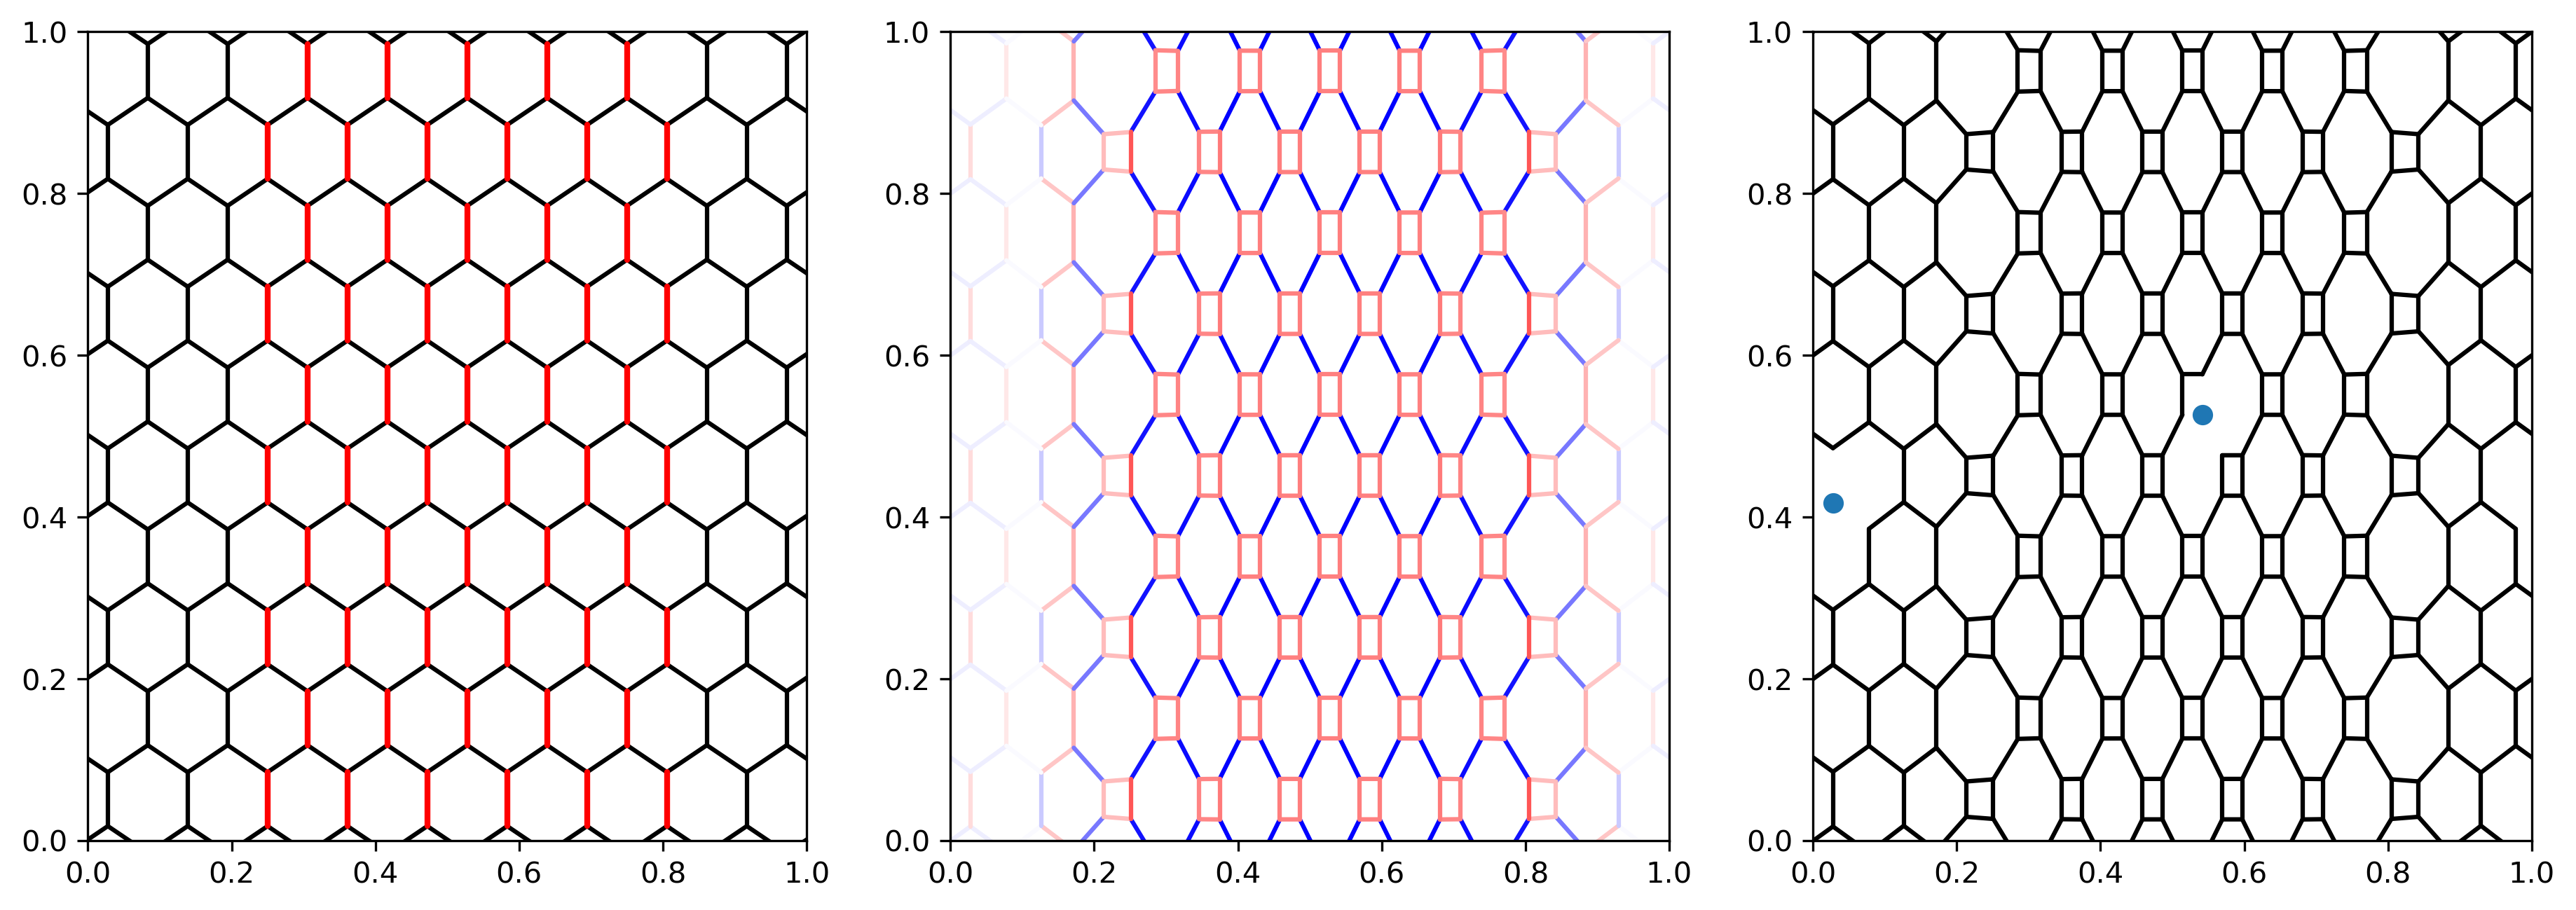

In [68]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5), dpi=300)
pl.plot_edges(lattice, ax=ax[0])
pl.plot_edges(
    lattice,
    subset=np.where(mask),
    ax=ax[0],
    color_scheme=["r", "y", "b"],
    linewidth=2,
)


edge_labels = np.arange(l2.n_edges)
cmap = plt.get_cmap("bwr")
color_scheme = cmap(probs + 0.5)  # Shift to center around 0

pl.plot_edges(
    l2,
    ax=ax[1],
    labels=edge_labels,
    color_scheme=color_scheme,
)

plt.scatter(*l2.vertices.positions[[v1, v2]].T, zorder=10)


pl.plot_edges(
    monomer_lattice,
    ax=ax[2],
)